**Importing Necessory Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import sklearn.metrics as metrics

**Mounting with Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DS_H_Features Face_Parts/DS_H_Features Forehead.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,DownSyndromeStatus
0,forehead_down_599.jpg,0.000000,0.037294,0.019448,1.399880,1.295987,0.033236,0.175212,0.034512,0.558553,...,0.588768,0.894645,0.042650,0.496749,0.000000,0.026925,0.284946,0.081930,0.000000,1
1,forehead_down_592.jpg,0.017309,0.081138,0.292077,0.236853,0.193925,0.373085,0.041211,0.527459,0.200322,...,3.525730,2.212519,0.000000,0.799141,0.011578,0.496721,0.055749,0.083378,0.010299,1
2,forehead_down_588.jpg,0.000000,0.001623,0.104840,0.249228,0.785039,0.465451,0.082350,0.036596,0.470432,...,3.300441,2.036561,0.000000,0.549745,0.000000,0.139130,0.153550,0.066500,0.000000,1
3,forehead_down_601.jpg,0.194862,0.119943,0.000000,1.537227,0.235487,0.119741,0.167957,0.065930,0.000000,...,1.289810,0.964625,0.025401,0.000000,0.000000,0.000000,0.336441,0.000000,0.035304,1
4,forehead_down_591.jpg,0.005393,0.004253,0.051770,0.000000,1.912603,0.097081,0.072954,0.351228,0.172258,...,5.757210,1.370427,0.047588,0.921635,0.000000,0.000000,0.356060,0.183100,0.002010,1


In [ ]:
#checking for null values
df.isnull().sum()

,0
image_name,0
0,0
1,0
2,0
3,0
...,...
2044,0
2045,0
2046,0
2047,0


In [ ]:
#null value count
df.isnull().sum().sum()

0

In [ ]:
#Dropping the target coloumn (DownSyndromeStatus) and 'image_name' column as it's not relevant for prediction
X=df.drop(['DownSyndromeStatus','image_name'],axis=1)
y=df['DownSyndromeStatus']

In [ ]:
#Spliting the data with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Creating an SVM classifier
svm = SVC(kernel='linear', probability=True)  # 'probability=True' is required for ROC

#Fitting model
svm.fit(X_train, y_train)

#Evaluating the Model
#Prediction on the test set
y_pred = svm.predict(X_test)

In [ ]:
#Calculating accuracy
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)


#Classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.76
Confusion Matrix:
[[217  75]
 [ 68 234]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       292
           1       0.76      0.77      0.77       302

    accuracy                           0.76       594
   macro avg       0.76      0.76      0.76       594
weighted avg       0.76      0.76      0.76       594



**Confusion Matrix**

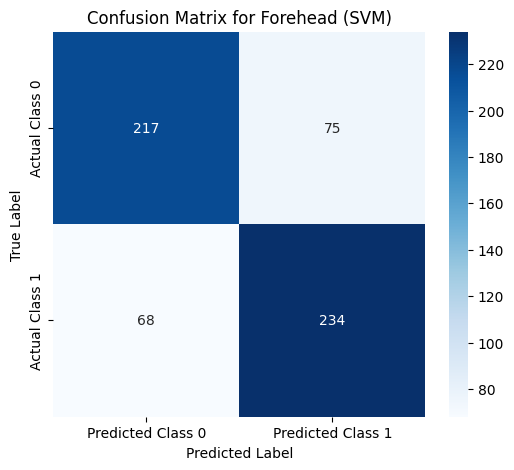

In [ ]:
#Creating heatmap for confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Class 0', 'Predicted Class 1'],
            yticklabels=['Actual Class 0', 'Actual Class 1'])

#giving labels, title, and displaying the plot
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Forehead (SVM)')
plt.show()

**Area Under the Curve Score**

In [ ]:
#Getting the decision function scores for the test set
y_scores = svm.decision_function(X_test)

#Computing False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

#Calculating AUC
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.2f}')

AUC: 0.83


**ROC (Receiver Operating Characteristic) Curve**

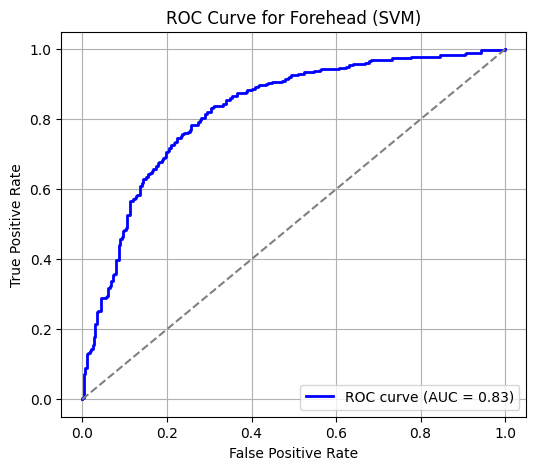

In [ ]:
#Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

#Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Forehead (SVM)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()